# TSP Training Metrics

This notebook reads `results/models_TSP_epochs.json` and plots the main epoch metrics saved by `train.py`.

If your notebook kernel is missing matplotlib, run `%pip install matplotlib` once in a new cell.

In [2]:
from pathlib import Path
import json
import math

DEFAULT_RESULTS_PATH = Path('results/models_TSP_epochs.json')


def read_epoch_results(path=DEFAULT_RESULTS_PATH):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Results file not found: {path}')

    with path.open('r') as f:
        data = json.load(f)

    metadata = data.get('metadata', {})
    epochs = data.get('epochs', [])
    if not isinstance(epochs, list):
        raise ValueError('Expected the JSON to contain an epochs list.')

    return metadata, epochs


def flatten_epoch_records(epochs):
    rows = []
    for record in epochs:
        row = {
            'epoch': record.get('epoch'),
            'saved_best': record.get('saved_best'),
        }
        for split in ('train', 'validation'):
            metrics = record.get(split, {}) or {}
            for name, value in metrics.items():
                if isinstance(value, (int, float)) and not isinstance(value, bool):
                    row[f'{split}.{name}'] = float(value)
        rows.append(row)
    return rows


def metric_series(rows, metric_name):
    xs = []
    ys = []
    for row in rows:
        epoch = row.get('epoch')
        value = row.get(metric_name)
        if isinstance(epoch, (int, float)) and isinstance(value, (int, float)) and math.isfinite(value):
            xs.append(epoch)
            ys.append(value)
    return xs, ys


def rolling_mean(values, window):
    if window <= 1:
        return list(values)

    smoothed = []
    active_values = []
    total = 0.0
    for value in values:
        active_values.append(value)
        total += value
        if len(active_values) > window:
            total -= active_values.pop(0)
        smoothed.append(total / len(active_values))
    return smoothed


def best_epoch(rows, metric_name, lower_is_better=True):
    values = []
    for row in rows:
        value = row.get(metric_name)
        if isinstance(value, (int, float)) and math.isfinite(value):
            values.append((row.get('epoch'), value))

    if not values:
        return None
    return min(values, key=lambda item: item[1]) if lower_is_better else max(values, key=lambda item: item[1])


def summarize_epoch_results(rows, metadata):
    lines = [
        f"model_dir: {metadata.get('model_dir', '<unknown>')}",
        f"config: {metadata.get('config', '<unknown>')}",
        f'epochs loaded: {len(rows)}',
    ]

    summary_metrics = [
        ('best validation solved_ratio', 'validation.solved_ratio', False),
        ('best validation unsat_count', 'validation.unsat_count', True),
        ('best validation tsp_objective', 'validation.tsp_objective', True),
        ('best validation tsp_tour_cost', 'validation.tsp_tour_cost', True),
        ('best train loss', 'train.loss', True),
    ]
    for label, metric_name, lower_is_better in summary_metrics:
        best = best_epoch(rows, metric_name, lower_is_better=lower_is_better)
        if best is not None:
            epoch, value = best
            lines.append(f'{label}: epoch {epoch}, value {value:.6g}')

    last = rows[-1] if rows else {}
    for metric_name in ('validation.solved_ratio', 'validation.unsat_count', 'validation.tsp_objective'):
        value = last.get(metric_name)
        if isinstance(value, (int, float)):
            lines.append(f'latest {metric_name}: {value:.6g}')

    return lines


def clean_label(metric_name):
    return metric_name.replace('validation.', 'val ').replace('train.', 'train ').replace('_', ' ')


def plot_epoch_metrics(path=DEFAULT_RESULTS_PATH, smooth_window=10, figsize=(15, 12)):
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            'matplotlib is required to draw these charts. Install it in this notebook kernel with `%pip install matplotlib`.'
        ) from exc

    metadata, epochs = read_epoch_results(path)
    rows = flatten_epoch_records(epochs)
    if not rows:
        raise ValueError(f'No epoch records found in {path}.')

    print('\n'.join(summarize_epoch_results(rows, metadata)))

    chart_specs = [
        ('Solved ratio', ['train.solved_ratio', 'validation.solved_ratio'], 'higher is better'),
        ('Unsat count', ['train.unsat_count', 'validation.unsat_count'], 'lower is better'),
        ('TSP objective', ['train.tsp_objective', 'validation.tsp_objective'], 'lower is better'),
        ('TSP tour cost', ['train.tsp_tour_cost', 'validation.tsp_tour_cost'], 'lower is better'),
        (
            'TSP penalties',
            [
                'train.tsp_duplicate_penalty',
                'validation.tsp_duplicate_penalty',
                'train.tsp_missing_edge_penalty',
                'validation.tsp_missing_edge_penalty',
            ],
            'lower is better',
        ),
        ('Training loss', ['train.loss'], 'lower is better'),
    ]

    available_charts = []
    for title, metric_names, direction in chart_specs:
        available_metrics = [name for name in metric_names if metric_series(rows, name)[0]]
        if available_metrics:
            available_charts.append((title, available_metrics, direction))

    if not available_charts:
        raise ValueError('No numeric metrics were available to plot.')

    ncols = 2
    nrows = math.ceil(len(available_charts) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = [axis for row_axes in axes for axis in row_axes]
    smoothing_label = f'{smooth_window}-epoch rolling mean' if smooth_window > 1 else 'raw values'

    for axis, (title, metric_names, direction) in zip(axes, available_charts):
        for metric_name in metric_names:
            xs, ys = metric_series(rows, metric_name)
            axis.plot(xs, rolling_mean(ys, smooth_window), linewidth=1.8, label=clean_label(metric_name))

        axis.set_title(f'{title} ({direction}, {smoothing_label})')
        axis.set_xlabel('Epoch')
        axis.grid(True, alpha=0.25)
        axis.legend(fontsize=8)

    for axis in axes[len(available_charts):]:
        axis.axis('off')

    model_dir = metadata.get('model_dir', 'model')
    fig.suptitle(f'{model_dir} epoch metrics from {path}', fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

    return rows, metadata, fig


model_dir: models/TSP
config: configs/TSP/TSP_default.json
epochs loaded: 1000
best validation solved_ratio: epoch 1, value 0
best validation unsat_count: epoch 676, value 1.05
best validation tsp_objective: epoch 634, value 1948.9
best validation tsp_tour_cost: epoch 307, value 283.5
best train loss: epoch 491, value 3.87305
latest validation.solved_ratio: 0
latest validation.unsat_count: 1.6
latest validation.tsp_objective: 2271.4


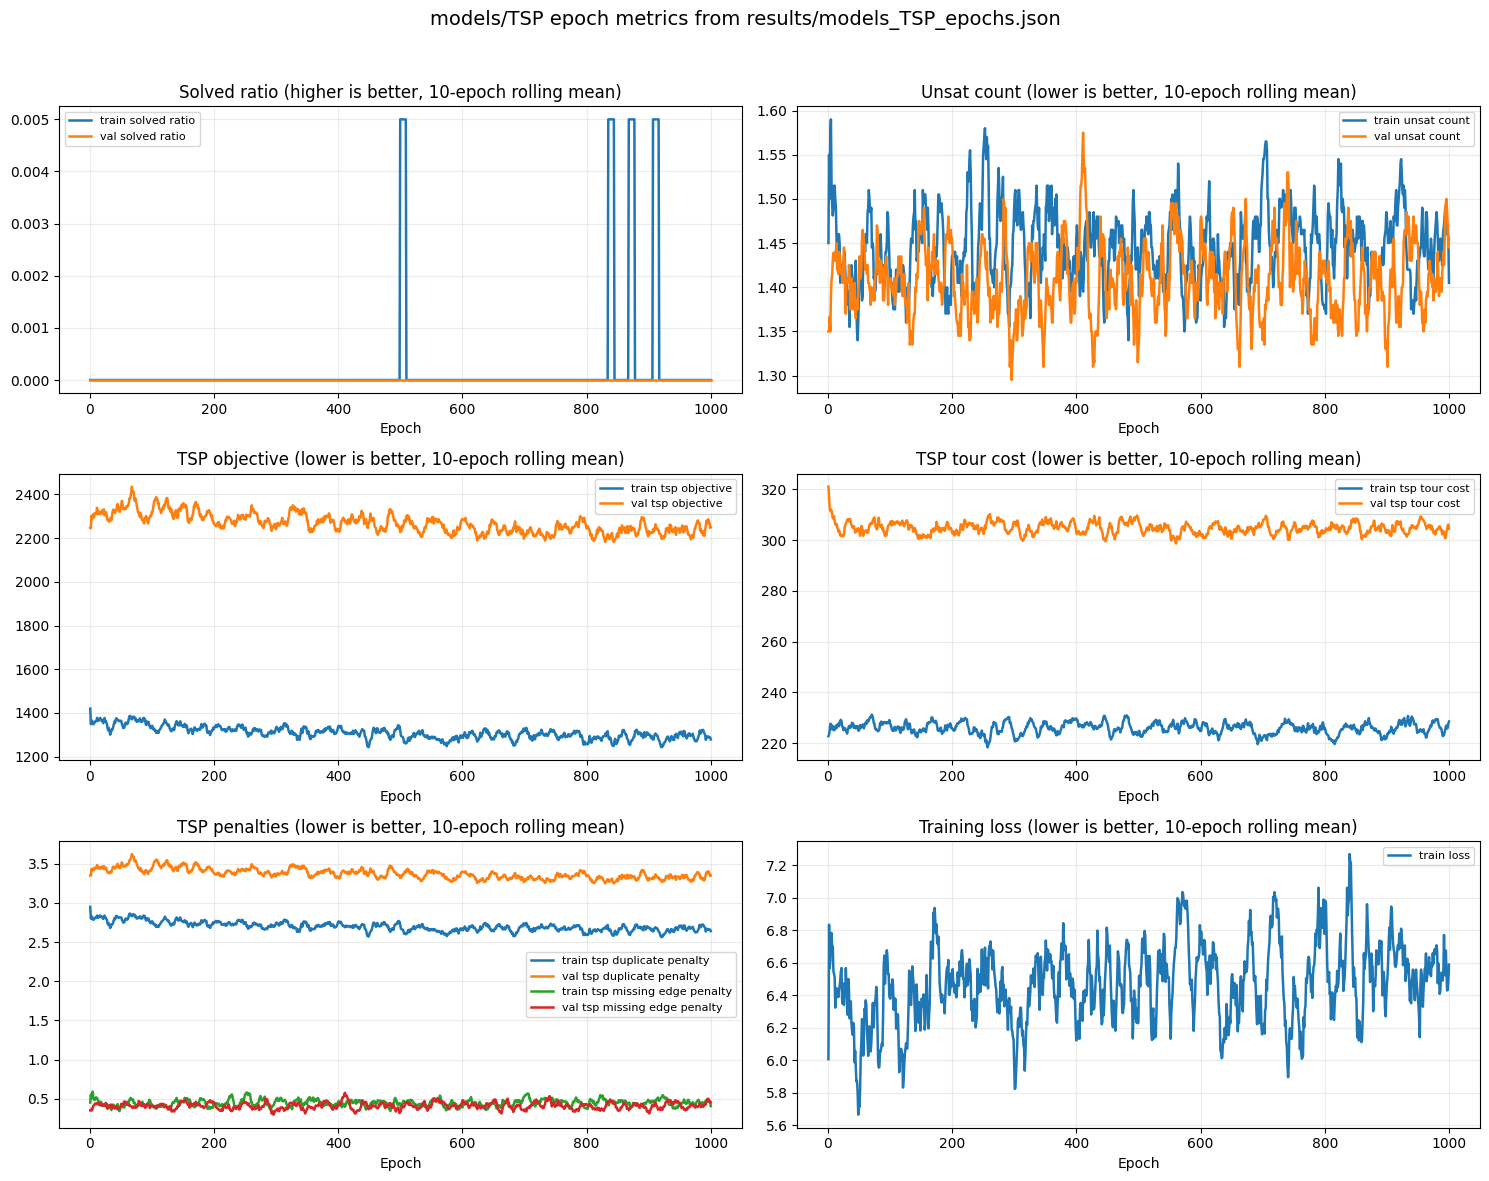

In [4]:
rows, metadata, fig = plot_epoch_metrics('results/models_TSP_epochs.json', smooth_window=10)
